ОТБОР СБАЛАНСИРОВАННЫХ ПАТЧЕЙ С RLE РАЗМЕТКОЙ (70/15/15)
✅ Загружено: 15987 патчей, 4 классов

📊 РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:
  defect_type_1: 1568 патчей
  defect_type_2: 263 патчей
  defect_type_3: 12402 патчей
  defect_type_4: 2039 патчей

🎯 МИНОРИТАРНЫЙ КЛАСС: defect_type_2 (263 патчей)

📦 ОТБОР И РАЗБИЕНИЕ:
  defect_type_1: 526 патчей (train:368, val:78, test:80)
  defect_type_2: 263 патчей (train:184, val:39, test:40)
  defect_type_3: 526 патчей (train:368, val:78, test:80)
  defect_type_4: 526 патчей (train:368, val:78, test:80)

✅ ВСЕГО: train=1288, val=273, test=280

📁 КОПИРОВАНИЕ:
  Train: 1288 img, 1288 lbl
  Val:   273 img, 273 lbl
  Test:  280 img, 280 lbl

💾 СОХРАНЕНИЕ RLE РАЗМЕТКИ:
  ✅ train: 1517 RLE записей → data/256_yolo/balanced_defect_patches_rle_v2/train/train_rle.csv
  ✅ val: 317 RLE записей → data/256_yolo/balanced_defect_patches_rle_v2/val/val_rle.csv
  ✅ test: 331 RLE записей → data/256_yolo/balanced_defect_patches_rle_v2/test/test_rle.csv
  📊 Всего RLE записей: 

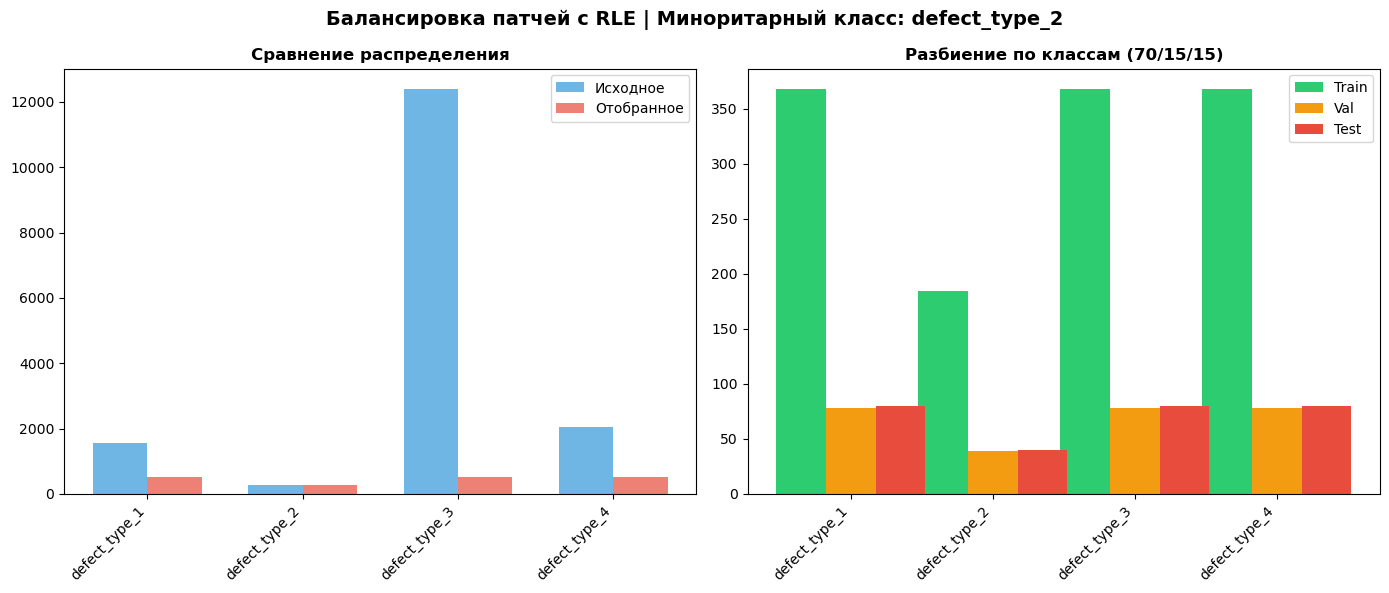


✅ ГОТОВО! RLE РАЗМЕТКА СОХРАНЕНА!

📍 Выходная директория: data/256_yolo/balanced_defect_patches_rle_v2
   ├── train/ (img:1288, lbl:1288, rle:1288 записей)
   ├── val/   (img:273, lbl:273, rle:273 записей)
   ├── test/  (img:280, lbl:280, rle:280 записей)
   ├── *_rle.csv (RLE разметка для каждого сплита)
   └── *.csv, *.json, *.yaml, *.png


In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import json
import yaml
import shutil
from collections import defaultdict
import random
import ast
import matplotlib.pyplot as plt
import re

# ============================================
# НАСТРОЙКИ (ИЗМЕНЕН ТОЛЬКО OUTPUT_PATH)
# ============================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DATA_PATH = Path("data/256_yolo/defect_patches")
OUTPUT_PATH = Path("data/256_yolo/balanced_defect_patches_rle_v2")  # <-- НОВЫЙ ПУТЬ
IMAGES_PATH = DATA_PATH / "images" / "train"
LABELS_PATH = DATA_PATH / "labels" / "train"
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

print("="*80)
print("ОТБОР СБАЛАНСИРОВАННЫХ ПАТЧЕЙ С RLE РАЗМЕТКОЙ (70/15/15)")
print("="*80)

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ (БЕЗ ИЗМЕНЕНИЙ)
# ============================================
metadata = pd.read_csv(DATA_PATH / "patches_metadata.csv")
with open(DATA_PATH / "annotations.json", 'r', encoding='utf-8') as f:
    annotations = json.load(f)
with open(DATA_PATH / "dataset.yaml", 'r', encoding='utf-8') as f:
    dataset_config = yaml.safe_load(f)

class_names = dataset_config.get('names', [])
real_images = {img.stem: img.name for img in IMAGES_PATH.glob("*.png")}
real_images.update({img.stem: img.name for img in IMAGES_PATH.glob("*.jpg")})
real_labels = {lbl.stem: lbl.name for lbl in LABELS_PATH.glob("*.txt")}
ann_dict = {ann['saved_as']: ann for ann in annotations}

print(f"✅ Загружено: {len(metadata)} патчей, {len(class_names)} классов")

# ============================================
# 2. АНАЛИЗ ПАТЧЕЙ ПО КЛАССАМ (БЕЗ ИЗМЕНЕНИЙ)
# ============================================
patches_by_class = defaultdict(list)

for idx, row in metadata.iterrows():
    patch_name = row['saved_as']
    base_name = patch_name.replace('.png', '').replace('.jpg', '')
    if base_name not in real_images:
        continue
    
    ann = ann_dict.get(patch_name, {})
    classes_in_patch = set()
    if 'classes' in ann:
        classes_in_patch = set(ann['classes'])
    elif 'classes_present' in row:
        val = row['classes_present']
        if isinstance(val, str):
            try:
                classes_list = ast.literal_eval(val)
            except:
                classes_list = [int(x.strip()) for x in val.strip('[]').split(',') if x.strip()]
        else:
            classes_list = val
        classes_in_patch = set(classes_list if isinstance(classes_list, list) else [classes_list])
    
    for c in classes_in_patch:
        class_id = c - 1 if c >= 1 and c <= 4 else c
        patches_by_class[class_id].append((patch_name, base_name, row, ann))

actual_class_ids = sorted(patches_by_class.keys())
print(f"\n📊 РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:")
for cid in actual_class_ids:
    print(f"  {class_names[cid]}: {len(patches_by_class[cid])} патчей")

min_class = min(actual_class_ids, key=lambda x: len(patches_by_class[x]))
min_count = len(patches_by_class[min_class])
min_name = class_names[min_class]
print(f"\n🎯 МИНОРИТАРНЫЙ КЛАСС: {min_name} ({min_count} патчей)")

# ============================================
# 3. ОТБОР ПАТЧЕЙ И РАЗБИЕНИЕ (БЕЗ ИЗМЕНЕНИЙ)
# ============================================
print(f"\n📦 ОТБОР И РАЗБИЕНИЕ:")

selected_by_split = {'train': [], 'val': [], 'test': []}
selected_by_class = defaultdict(lambda: {'train': [], 'val': [], 'test': []})
final_counts = defaultdict(int)

for class_id in actual_class_ids:
    patches = patches_by_class[class_id]
    random.shuffle(patches)
    
    if class_id == min_class:
        target = min_count
    else:
        target = min(min_count * 2, len(patches))
    
    selected_patches = patches[:target]
    random.shuffle(selected_patches)
    
    train_end = int(target * TRAIN_RATIO)
    val_end = train_end + int(target * VAL_RATIO)
    
    splits = {
        'train': selected_patches[:train_end],
        'val': selected_patches[train_end:val_end],
        'test': selected_patches[val_end:]
    }
    
    for split_name, split_patches in splits.items():
        selected_by_split[split_name].extend([p[0] for p in split_patches])
        selected_by_class[class_id][split_name] = [p[0] for p in split_patches]
        final_counts[class_id] += len(split_patches)
    
    name = class_names[class_id]
    print(f"  {name}: {final_counts[class_id]} патчей (train:{len(splits['train'])}, val:{len(splits['val'])}, test:{len(splits['test'])})")

print(f"\n✅ ВСЕГО: train={len(selected_by_split['train'])}, val={len(selected_by_split['val'])}, test={len(selected_by_split['test'])}")

# ============================================
# 4. КОПИРОВАНИЕ ФАЙЛОВ (БЕЗ ИЗМЕНЕНИЙ)
# ============================================
print(f"\n📁 КОПИРОВАНИЕ:")

if OUTPUT_PATH.exists():
    shutil.rmtree(OUTPUT_PATH)

new_metadata = {'train': [], 'val': [], 'test': []}
new_annotations = {'train': [], 'val': [], 'test': []}
copied = {'train': {'img': 0, 'lbl': 0}, 'val': {'img': 0, 'lbl': 0}, 'test': {'img': 0, 'lbl': 0}}

for split_name in ['train', 'val', 'test']:
    (OUTPUT_PATH / split_name / "images").mkdir(parents=True)
    (OUTPUT_PATH / split_name / "labels").mkdir(parents=True)

for split_name in ['train', 'val', 'test']:
    for patch_name in selected_by_split[split_name]:
        base_name = patch_name.replace('.png', '').replace('.jpg', '')
        real_img = real_images.get(base_name)
        real_lbl = real_labels.get(base_name)
        
        if real_img:
            shutil.copy2(IMAGES_PATH / real_img, OUTPUT_PATH / split_name / "images" / real_img)
            copied[split_name]['img'] += 1
            
            for _, row in metadata.iterrows():
                if row['saved_as'] == patch_name:
                    row_copy = row.copy()
                    row_copy['saved_as'] = real_img
                    row_copy['split'] = split_name
                    new_metadata[split_name].append(row_copy)
                    break
        
        if real_lbl:
            shutil.copy2(LABELS_PATH / real_lbl, OUTPUT_PATH / split_name / "labels" / real_lbl)
            copied[split_name]['lbl'] += 1
        
        ann = ann_dict.get(patch_name, {})
        if ann:
            ann_copy = ann.copy()
            ann_copy['id'] = len(new_annotations[split_name])
            ann_copy['split'] = split_name
            if real_img:
                ann_copy['saved_as'] = real_img
            new_annotations[split_name].append(ann_copy)

print(f"  Train: {copied['train']['img']} img, {copied['train']['lbl']} lbl")
print(f"  Val:   {copied['val']['img']} img, {copied['val']['lbl']} lbl")
print(f"  Test:  {copied['test']['img']} img, {copied['test']['lbl']} lbl")

# ============================================
# 5. СОХРАНЕНИЕ RLE ДАННЫХ (ГЛАВНОЕ ИЗМЕНЕНИЕ)
# ============================================
print(f"\n💾 СОХРАНЕНИЕ RLE РАЗМЕТКИ:")

# Загружаем оригинальные RLE данные
original_df = pd.read_csv("data/severstal/train.csv")

# Создаем словари для быстрого поиска RLE
rle_by_image = defaultdict(list)
for _, row in original_df.iterrows():
    rle_by_image[row['ImageId']].append({
        'ClassId': row['ClassId'],
        'EncodedPixels': row['EncodedPixels']
    })

# Функция для сохранения RLE в CSV
def rle_to_mask_full(rle_string, width=1600, height=256):
    """Преобразует RLE в полную маску изображения."""
    if pd.isna(rle_string) or str(rle_string).strip().lower() in ['', 'nan']:
        return None
    
    try:
        numbers = list(map(int, str(rle_string).split()))
    except ValueError:
        return None
    
    starts = np.array(numbers[0::2]) - 1
    lengths = np.array(numbers[1::2])
    
    mask = np.zeros(width * height, dtype=np.uint8)
    for start, length in zip(starts, lengths):
        if 0 <= start < len(mask):
            mask[start:min(start + length, len(mask))] = 1
    
    return mask.reshape(height, width)  # (256, 1600)


def mask_to_rle(mask):
    """Преобразует маску обратно в RLE строку."""
    if mask.sum() == 0:
        return ''
    
    # Flatten маску построчно (как в оригинальном RLE)
    flat_mask = mask.flatten()
    
    rle_parts = []
    prev_val = 0
    run_start = 0
    
    for i, val in enumerate(flat_mask):
        if val != prev_val:
            if prev_val == 1:
                rle_parts.append(str(run_start + 1))  # +1 потому что RLE индексация с 1
                rle_parts.append(str(i - run_start))
            run_start = i
            prev_val = val
    
    if prev_val == 1:
        rle_parts.append(str(run_start + 1))
        rle_parts.append(str(len(flat_mask) - run_start))
    
    return ' '.join(rle_parts)


def parse_patch_offset(filename):
    """Извлекает смещение и ширину патча из имени файла."""
    m = re.search(r'_x(\d+)_w(\d+)', filename)
    if m:
        return int(m.group(1)), int(m.group(2))
    return 0, 256


def save_rle_for_split(split_name, selected_patches, output_dir):
    rle_data = []
    
    for patch_name in selected_patches:
        # Извлекаем имя оригинального изображения из имени патча
        base_name = patch_name.replace('.png', '').replace('.jpg', '')
        parts = base_name.split('_x')
        if len(parts) >= 2:
            original_img_id = parts[0] + '.jpg'
        else:
            original_img_id = base_name + '.jpg'
        
        # Получаем offset_x и width патча
        offset_x, patch_w = parse_patch_offset(patch_name)
        
        # Получаем все RLE для этого изображения
        if original_img_id in rle_by_image:
            for rle_info in rle_by_image[original_img_id]:
                # Преобразуем RLE в полную маску 256×1600
                full_mask = rle_to_mask_full(rle_info['EncodedPixels'])
                
                if full_mask is not None:
                    # Вырезаем маску патча: все строки (256), колонки от offset_x до offset_x + patch_w
                    patch_mask = full_mask[:, offset_x:offset_x + patch_w]  # (256, patch_w)
                    
                    # Ресайзим до 256×256 если нужно
                    if patch_w != 256:
                        patch_mask = cv2.resize(patch_mask, (256, 256), interpolation=cv2.INTER_NEAREST)
                        patch_mask = (patch_mask > 0.5).astype(np.uint8)
                    
                    # Конвертируем обратно в RLE
                    new_rle = mask_to_rle(patch_mask)
                    
                    if new_rle:  # Добавляем только если есть дефекты в патче
                        # Добавляем .png к имени патча
                        if not patch_name.endswith('.png'):
                            patch_name_with_ext = patch_name + '.png'
                        else:
                            patch_name_with_ext = patch_name
                        
                        rle_data.append({
                            'ImageId': patch_name_with_ext,
                            'ClassId': rle_info['ClassId'],
                            'EncodedPixels': new_rle
                        })
    
    # Сохраняем в CSV
    df_rle = pd.DataFrame(rle_data)
    csv_path = output_dir / split_name / f"{split_name}_rle.csv"
    df_rle.to_csv(csv_path, index=False)
    print(f"  ✅ {split_name}: {len(df_rle)} RLE записей → {csv_path}")
    
    return len(df_rle)

# Сохраняем RLE для каждого сплита
total_rle = 0
for split_name in ['train', 'val', 'test']:
    count = save_rle_for_split(split_name, selected_by_split[split_name], OUTPUT_PATH)
    total_rle += count

print(f"  📊 Всего RLE записей: {total_rle}")

# ============================================
# 6. СОХРАНЕНИЕ ОСТАЛЬНЫХ МЕТАДАННЫХ
# ============================================
all_metadata = pd.concat([pd.DataFrame(new_metadata[s]) for s in ['train', 'val', 'test']])
all_metadata.to_csv(OUTPUT_PATH / "patches_metadata.csv", index=False)

all_annotations = new_annotations['train'] + new_annotations['val'] + new_annotations['test']
with open(OUTPUT_PATH / "annotations.json", 'w', encoding='utf-8') as f:
    json.dump(all_annotations, f, indent=2, ensure_ascii=False)

dataset_config['path'] = str(OUTPUT_PATH.absolute())
dataset_config['train'] = 'train/images'
dataset_config['val'] = 'val/images'
dataset_config['test'] = 'test/images'

with open(OUTPUT_PATH / "dataset.yaml", 'w', encoding='utf-8') as f:
    yaml.dump(dataset_config, f, default_flow_style=False, allow_unicode=True)

# ============================================
# 7. ВИЗУАЛИЗАЦИЯ (БЕЗ ИЗМЕНЕНИЙ)
# ============================================
all_ids = list(range(len(class_names)))
orig_counts = [len(patches_by_class.get(i, [])) for i in all_ids]
sel_counts = [final_counts.get(i, 0) for i in all_ids]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(class_names))
width = 0.35
axes[0].bar(x - width/2, orig_counts, width, label='Исходное', color='#3498db', alpha=0.7)
axes[0].bar(x + width/2, sel_counts, width, label='Отобранное', color='#e74c3c', alpha=0.7)
axes[0].set_title('Сравнение распределения', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].legend()

train_counts = [len(selected_by_class.get(i, {}).get('train', [])) for i in all_ids]
val_counts = [len(selected_by_class.get(i, {}).get('val', [])) for i in all_ids]
test_counts = [len(selected_by_class.get(i, {}).get('test', [])) for i in all_ids]

axes[1].bar(x - width, train_counts, width, label='Train', color='#2ecc71')
axes[1].bar(x, val_counts, width, label='Val', color='#f39c12')
axes[1].bar(x + width, test_counts, width, label='Test', color='#e74c3c')
axes[1].set_title('Разбиение по классам (70/15/15)', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].legend()

plt.suptitle(f'Балансировка патчей с RLE | Миноритарный класс: {min_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'selection_analysis.png', dpi=150)
plt.show()

print("\n" + "="*80)
print("✅ ГОТОВО! RLE РАЗМЕТКА СОХРАНЕНА!")
print("="*80)
print(f"\n📍 Выходная директория: {OUTPUT_PATH}")
print(f"   ├── train/ (img:{copied['train']['img']}, lbl:{copied['train']['lbl']}, rle:{copied['train']['img']} записей)")
print(f"   ├── val/   (img:{copied['val']['img']}, lbl:{copied['val']['lbl']}, rle:{copied['val']['img']} записей)")
print(f"   ├── test/  (img:{copied['test']['img']}, lbl:{copied['test']['lbl']}, rle:{copied['test']['img']} записей)")
print(f"   ├── *_rle.csv (RLE разметка для каждого сплита)")
print(f"   └── *.csv, *.json, *.yaml, *.png")